In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load ground data
ground_folder_addr = "./all_merged_data/"
ground_csv_filenames = [f"Station{i}_AMSR_SMAP_Merged.csv" for i in range(1, 7)]

merged_sm_data = []
for filename in ground_csv_filenames:
    df = pd.read_csv(ground_folder_addr + filename, parse_dates=['Date'])
    df.set_index('Date', inplace=True)
    merged_sm_data.append(df)

In [3]:
# Function to compare satellite data with ground measurements
def compare_satellite_data(df, satellite_column, distance_column, ground_column, max_distance=20):
    # Calculate overall differences
    overall_diff = df[satellite_column] - df[ground_column]
    
    # Calculate differences for measurements within max_distance
    close_measurements = df[df[distance_column] <= max_distance]
    close_diff = close_measurements[satellite_column] - close_measurements[ground_column]
    
    # Plot histograms
    plt.figure(figsize=(12, 6))
    plt.hist(overall_diff, bins=50, alpha=0.5, label='All measurements')
    plt.hist(close_diff, bins=50, alpha=0.5, label=f'Within {max_distance} miles')
    plt.xlabel('Difference (Satellite - Ground)')
    plt.ylabel('Frequency')
    plt.title(f'Difference between {satellite_column} and {ground_column}')
    plt.legend()
    plt.show()
    
    # Print statistics
    print(f"Overall MSE: {(overall_diff ** 2).mean():.4f}")
    print(f"Overall MAE: {abs(overall_diff).mean():.4f}")
    print(f"Overall MAE Percentage: {(abs(overall_diff) / df[ground_column]).mean() * 100:.2f}%")
    print(f"\nMSE within {max_distance} miles: {(close_diff ** 2).mean():.4f}")
    print(f"MAE within {max_distance} miles: {abs(close_diff).mean():.4f}")
    print(f"MAE Percentage within {max_distance} miles: {(abs(close_diff) / close_measurements[ground_column]).mean() * 100:.2f}%")


Station 1
AMSR vs SWC_5:


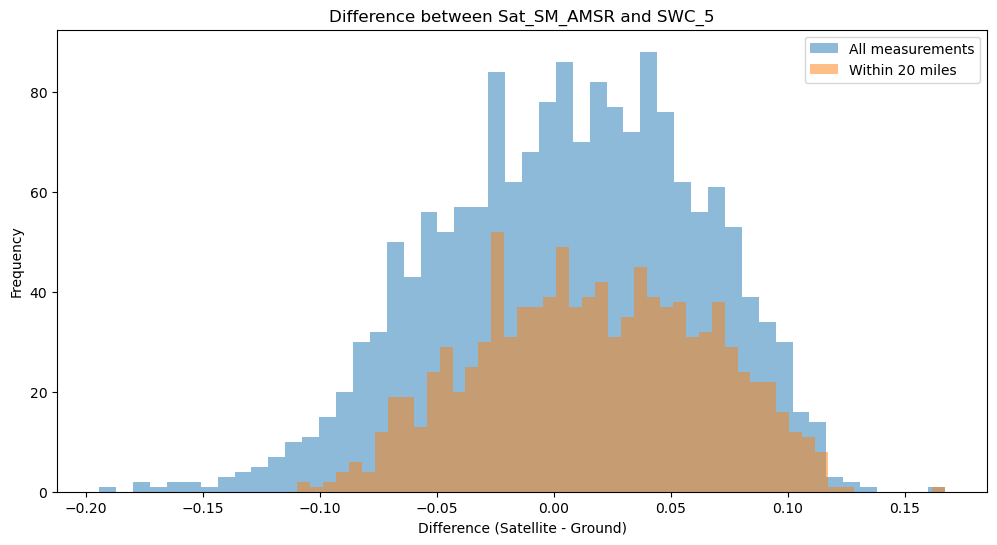

Overall MSE: 0.0031
Overall MAE: 0.0458
Overall MAE Percentage: 37.11%

MSE within 20 miles: 0.0027
MAE within 20 miles: 0.0426
MAE Percentage within 20 miles: 37.21%



Station 2
AMSR vs SWC_5:


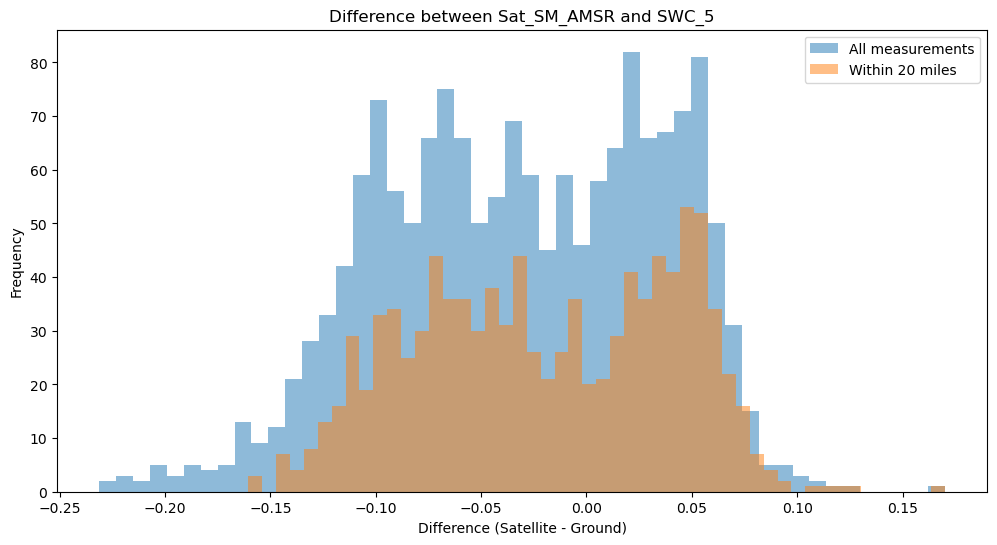

Overall MSE: 0.0053
Overall MAE: 0.0597
Overall MAE Percentage: 32.26%

MSE within 20 miles: 0.0040
MAE within 20 miles: 0.0541
MAE Percentage within 20 miles: 30.59%



Station 3
AMSR vs SWC_5:


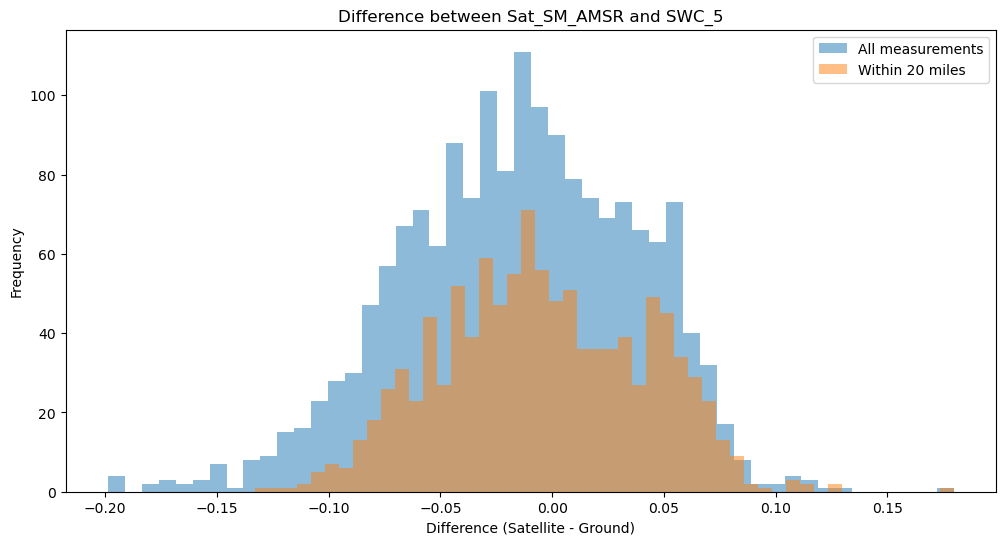

Overall MSE: 0.0030
Overall MAE: 0.0435
Overall MAE Percentage: 26.99%

MSE within 20 miles: 0.0021
MAE within 20 miles: 0.0377
MAE Percentage within 20 miles: 24.83%



Station 4
AMSR vs SWC_5:


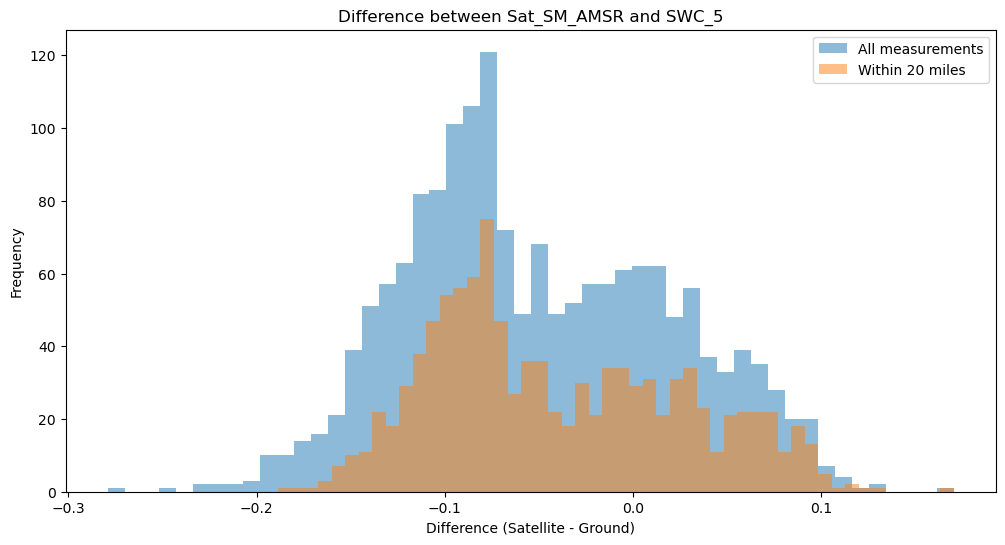

Overall MSE: 0.0075
Overall MAE: 0.0731
Overall MAE Percentage: 35.18%

MSE within 20 miles: 0.0060
MAE within 20 miles: 0.0670
MAE Percentage within 20 miles: 33.52%



Station 5
AMSR vs SWC_5:


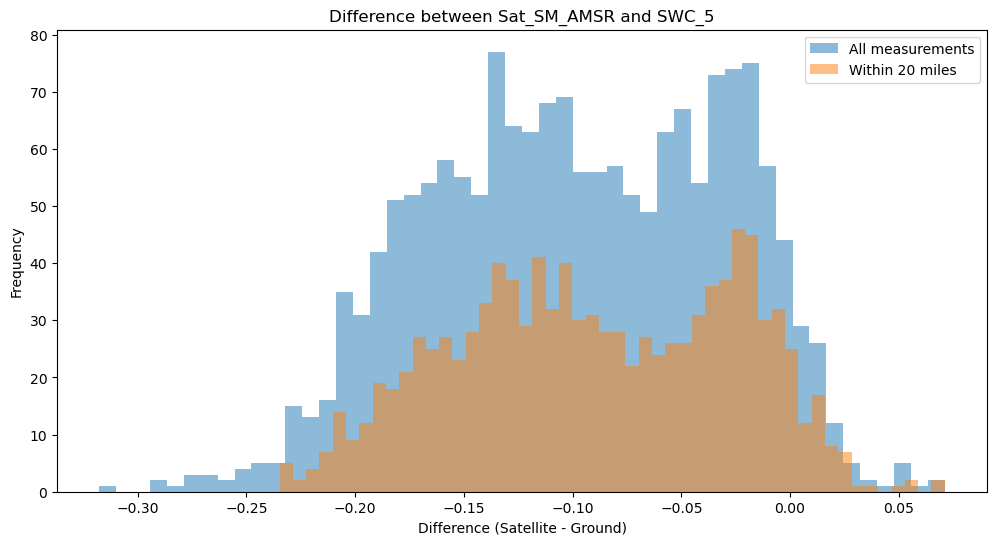

Overall MSE: 0.0141
Overall MAE: 0.0997
Overall MAE Percentage: 36.87%

MSE within 20 miles: 0.0120
MAE within 20 miles: 0.0915
MAE Percentage within 20 miles: 33.48%



Station 6
AMSR vs SWC_5:


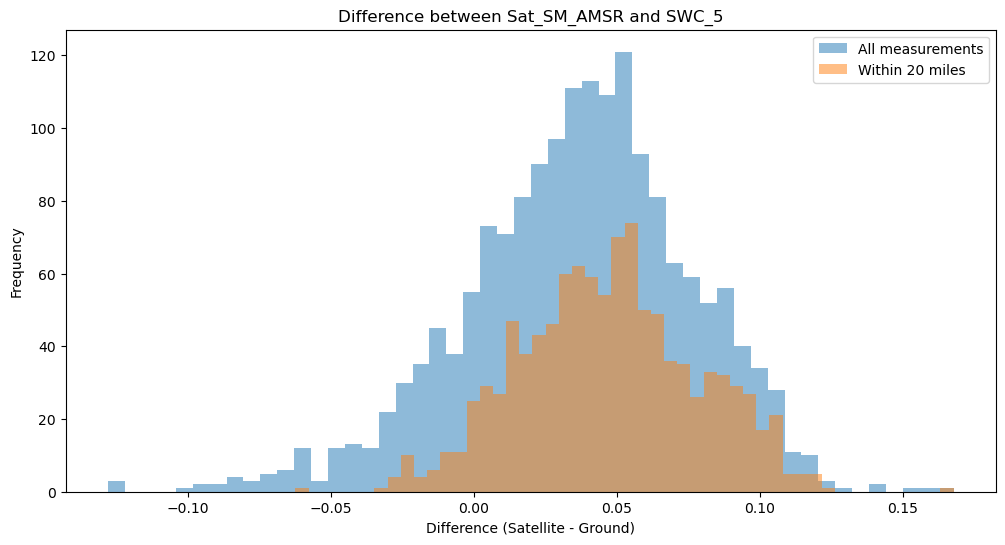

Overall MSE: 0.0029
Overall MAE: 0.0454
Overall MAE Percentage: 46.30%

MSE within 20 miles: 0.0032
MAE within 20 miles: 0.0488
MAE Percentage within 20 miles: 50.36%




In [4]:
# Analyze each station
for i, df in enumerate(merged_sm_data):
    print(f"\nStation {i+1}")
    print("AMSR vs SWC_5:")
    compare_satellite_data(df, 'Sat_SM_AMSR', 'distance_AMSR', 'SWC_5')
    print("\n" + "="*50 + "\n")

In [1]:
import pandas as pd
import numpy as np
import os

# Load ground data
ground_folder_addr = "./all_merged_data/"
ground_csv_filenames = [f"Station{i}_AMSR_SMAP_Merged.csv" for i in range(1, 7)]

merged_sm_data = []
for filename in ground_csv_filenames:
    df = pd.read_csv(ground_folder_addr + filename, parse_dates=['Date'])
    df.set_index('Date', inplace=True)
    merged_sm_data.append(df)

def compare_satellite_data(df, satellite_column, distance_column, ground_column):
    # Calculate overall statistics first
    overall_diff = df[satellite_column] - df[ground_column]
    overall_mse = (overall_diff ** 2).mean()
    overall_mae = abs(overall_diff).mean()
    overall_mae_percentage = (abs(overall_diff) / df[ground_column]).mean() * 100
    
    results = []
    for max_distance in range(15, 165, 5):
        close_measurements = df[df[distance_column] <= max_distance]
        close_diff = close_measurements[satellite_column] - close_measurements[ground_column]
        
        if len(close_diff) > 0:
            results.append({
                'Max Distance': max_distance,
                'MSE': (close_diff ** 2).mean(),
                'MAE': abs(close_diff).mean(),
                'MAE Percentage': (abs(close_diff) / close_measurements[ground_column]).mean() * 100,
                'Count': len(close_diff)
            })
    
    return pd.DataFrame(results), overall_mse, overall_mae, overall_mae_percentage

# Create lists to store all results
all_results = []

for i, df in enumerate(merged_sm_data):
    # Get results for AMSR
    amsr_results, amsr_overall_mse, amsr_overall_mae, amsr_overall_mae_pct = compare_satellite_data(
        df, 'Sat_SM_AMSR', 'distance_AMSR', 'SWC_5'
    )
    
    # Calculate minimums for AMSR
    min_mse = amsr_results['MSE'].min()
    min_dist_mse = amsr_results.loc[amsr_results['MSE'].idxmin(), 'Max Distance']
    min_mae = amsr_results['MAE'].min()
    min_dist_mae = amsr_results.loc[amsr_results['MAE'].idxmin(), 'Max Distance']
    min_mae_pct = amsr_results['MAE Percentage'].min()
    min_dist_mae_pct = amsr_results.loc[amsr_results['MAE Percentage'].idxmin(), 'Max Distance']
    
    # Add additional columns to results
    amsr_results['Station'] = i + 1
    amsr_results['Satellite'] = 'AMSR'
    amsr_results['Overall_MSE'] = amsr_overall_mse
    amsr_results['Overall_MAE'] = amsr_overall_mae
    amsr_results['Overall_MAE_Percentage'] = amsr_overall_mae_pct
    amsr_results['Min_MSE'] = min_mse
    amsr_results['Min_MSE_Distance'] = min_dist_mse
    amsr_results['Min_MAE'] = min_mae
    amsr_results['Min_MAE_Distance'] = min_dist_mae
    amsr_results['Min_MAE_Percentage'] = min_mae_pct
    amsr_results['Min_MAE_Percentage_Distance'] = min_dist_mae_pct
    
    all_results.append(amsr_results)

# Combine all results into a single DataFrame
final_results = pd.concat(all_results, ignore_index=True)

# Reorder columns for better readability
column_order = [
    'Station', 'Satellite', 'Max Distance', 
    'MSE', 'MAE', 'MAE Percentage', 'Count',
    'Overall_MSE', 'Overall_MAE', 'Overall_MAE_Percentage',
    'Min_MSE', 'Min_MSE_Distance',
    'Min_MAE', 'Min_MAE_Distance',
    'Min_MAE_Percentage', 'Min_MAE_Percentage_Distance'
]
final_results = final_results[column_order]

# Save to CSV
final_results.to_csv('distances.csv', index=False)

print("Analysis complete. Results written to distances.csv")

Analysis complete. Results written to distances.csv


In [2]:
# Create lists to store results
distance_results = []

for i, df in enumerate(merged_sm_data):
    station_num = i + 1
    
    # For each 5-mile increment
    for distance in range(5, 165, 5):
        # Filter data for current distance
        close_data = df[df['distance_AMSR'] <= distance]
        
        if len(close_data) > 0:
            # Calculate differences
            diff = close_data['Sat_SM_AMSR'] - close_data['SWC_5']
            
            # Calculate statistics
            result = {
                'Station': station_num,
                'Distance': distance,
                'Sample_Count': len(close_data),
                'MSE': (diff ** 2).mean(),
                'MAE': abs(diff).mean(),
                'MAE_Percentage': (abs(diff) / close_data['SWC_5']).mean() * 100,
                'Correlation': close_data['Sat_SM_AMSR'].corr(close_data['SWC_5'])
            }
            distance_results.append(result)

# Convert to DataFrame and save
distance_df = pd.DataFrame(distance_results)
distance_df.to_csv('distance_intervals.csv', index=False)

print("Analysis complete. Results written to distance_intervals.csv")

Analysis complete. Results written to distance_intervals.csv
